# `cost_reward_hacking_bo.py` results

Plots the summary/convergence CSVs produced by `cost_reward_hacking_bo.py`. See
`cost_reward_hacking_bo.md` in this directory for what the test does and why, and what each
chart below means to read correctly.

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path

RESULTS = Path("../results")
summary = pd.read_csv(RESULTS / "cost_reward_hacking_bo_summary.csv")
convergence = pd.read_csv(RESULTS / "cost_reward_hacking_bo_convergence.csv")

REFERENCE_ORDER = ["pooled", "dedicated_yield"]
VARIANT_ORDER = ["concentration_dense", "concentration_change", "mass_terminal", "mass_change_discharge"]
ALL_ORDER = REFERENCE_ORDER + VARIANT_ORDER
summary = summary.set_index("name").loc[ALL_ORDER].reset_index()

# Status colors carry VERDICT (a state), not candidate identity -- the two reference points
# (pooled search-time pick, dedicated yield-only BO) get their own neutral color since "verdict"
# doesn't apply to them the way it does to the 4 tested candidates.
STATUS_COLOR = {"PASS": "#2E7D32", "FAIL": "#C62828", "Δ~0": "#9E9E9E"}
REFERENCE_COLOR = "#1565C0"
CEILING_COLOR = "#37474F"

summary[["name", "is_ceiling", "mean_yield_env_valid", "gap_kg", "gap_pct", "p_value", "verdict"]]

,name,is_ceiling,mean_yield_env_valid,gap_kg,gap_pct,p_value,verdict
0,pooled,True,3880.415623,NaN,NaN,NaN,NaN
1,dedicated_yield,False,3852.793032,NaN,NaN,NaN,NaN
2,concentration_dense,False,3891.871314,-11.455692,-0.295218,0.515759,INCONCLUSIVE
3,concentration_change,False,1137.656201,2742.759422,70.682104,0.001254,FAIL
4,mass_terminal,False,1124.272425,2756.143198,71.027010,0.001094,FAIL
5,mass_change_discharge,False,3880.415623,0.000000,0.000000,NaN,INCONCLUSIVE


## Yield by reward function

Headline chart. Bars are **envelope-valid** yield (a batch that breaches the viscosity/Wt
envelope scores 0, not excluded) -- never raw yield, which is what lets a candidate "win" by
overfeeding into a breach. `pooled` is omitted (it's a search-time reference artifact, not a
reward function); `dedicated_yield` stays as the one non-tested reference point. No legend --
each bar is labeled directly with its yield, standard deviation, and verdict (plus breach count
where relevant), and the dashed line is labeled with the ceiling value directly.

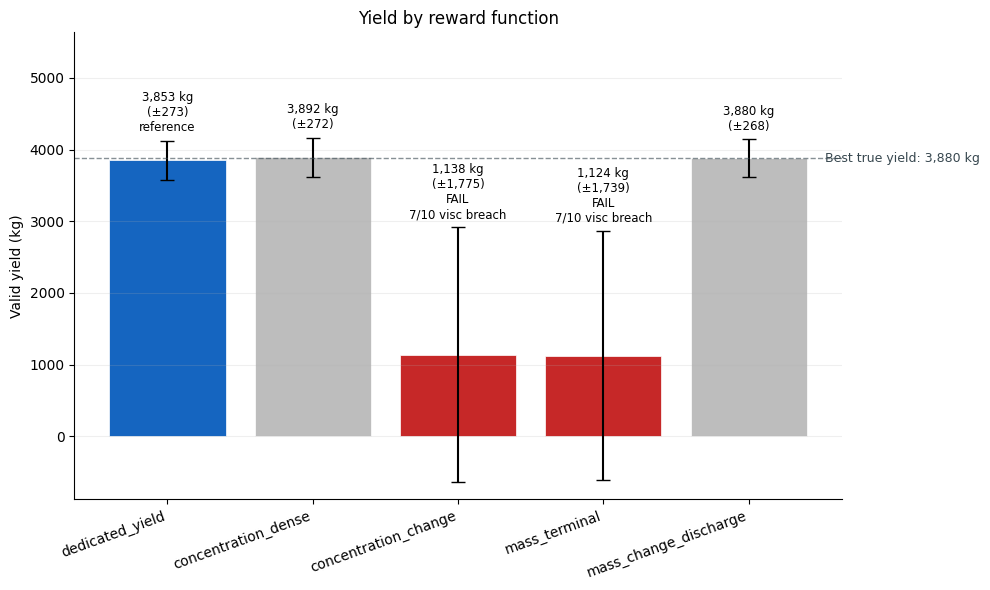

In [27]:
plot_df = summary[summary["name"] != "pooled"].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))

colors = [REFERENCE_COLOR if n == "dedicated_yield" else STATUS_COLOR.get(v, "#BDBDBD")
          for n, v in zip(plot_df["name"], plot_df["verdict"])]

ax.bar(plot_df["name"], plot_df["mean_yield_env_valid"], yerr=plot_df["sd_yield_env_valid"],
       color=colors, capsize=5, edgecolor="white", linewidth=0.5, error_kw={"linewidth": 1.5})

# No legend: identity/verdict is carried by these direct labels instead, not by color alone.
ceiling_val = summary.loc[summary["is_ceiling"], "mean_yield_env_valid"].iloc[0]
ax.axhline(ceiling_val, color=CEILING_COLOR, linestyle="--", linewidth=1, alpha=0.6)
ax.text(len(plot_df) - 0.5, ceiling_val, f" Best true yield: {ceiling_val:,.0f} kg", va="center",
        ha="left", fontsize=9, color=CEILING_COLOR)

for i, row in plot_df.iterrows():
    if row["name"] == "dedicated_yield":
        note = "reference"
    elif row["verdict"] == "INCONCLUSIVE":
        note = ""
    else:
        note = row["verdict"]
    if row["n_visc_breach"] or row["n_wt_breach"]:
        note += f"\n{row['n_visc_breach']}/{int(row['n_test_seeds'])} visc breach"
    top = row["mean_yield_env_valid"] + row["sd_yield_env_valid"]
    label = f"{row['mean_yield_env_valid']:,.0f} kg\n(±{row['sd_yield_env_valid']:,.0f})"
    if note:
        label += f"\n{note}"
    ax.text(i, top + 90, label, ha="center", va="bottom", fontsize=8.5)

ax.set_ylabel("Valid yield (kg)")
ax.set_title("Yield by reward function")
ax.set_ylim(top=ax.get_ylim()[1] * 1.28)
plt.xticks(rotation=20, ha="right")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

## Raw vs envelope-valid yield

How much the envelope gate changes the picture for each candidate. A big drop from raw (gray) to
envelope-valid (blue) means that candidate's winning profile relies on batches that would be
operationally rejected.

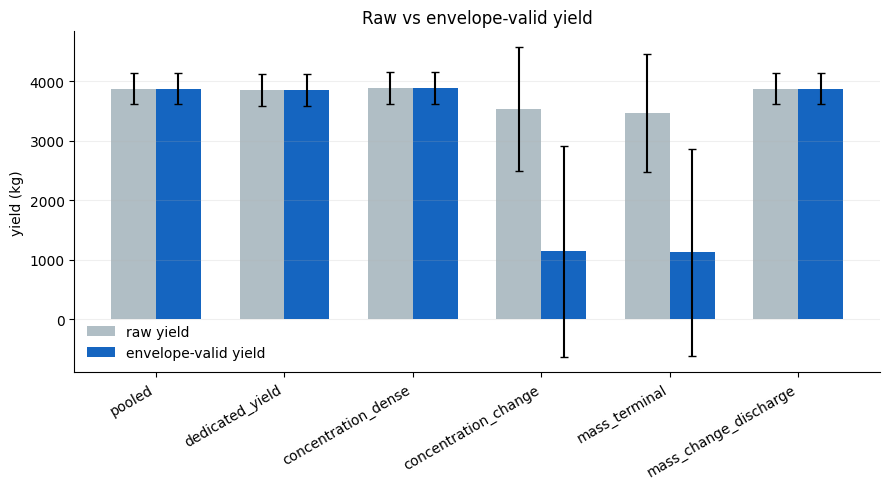

In [28]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(summary))
width = 0.35
ax.bar(x - width/2, summary["mean_yield_raw"], width, yerr=summary["sd_yield_raw"],
       label="raw yield", color="#B0BEC5", capsize=3)
ax.bar(x + width/2, summary["mean_yield_env_valid"], width, yerr=summary["sd_yield_env_valid"],
       label="envelope-valid yield", color=REFERENCE_COLOR, capsize=3)
ax.set_xticks(x)
ax.set_xticklabels(summary["name"], rotation=30, ha="right")
ax.set_ylabel("yield (kg)")
ax.set_title("Raw vs envelope-valid yield")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

## Operating envelope breaches

Count of test seeds (out of the total shown on the y-axis label) whose rollout breached
`VISC_MAX` or `WT_OVERFLOW`, per candidate -- including the ceiling itself.

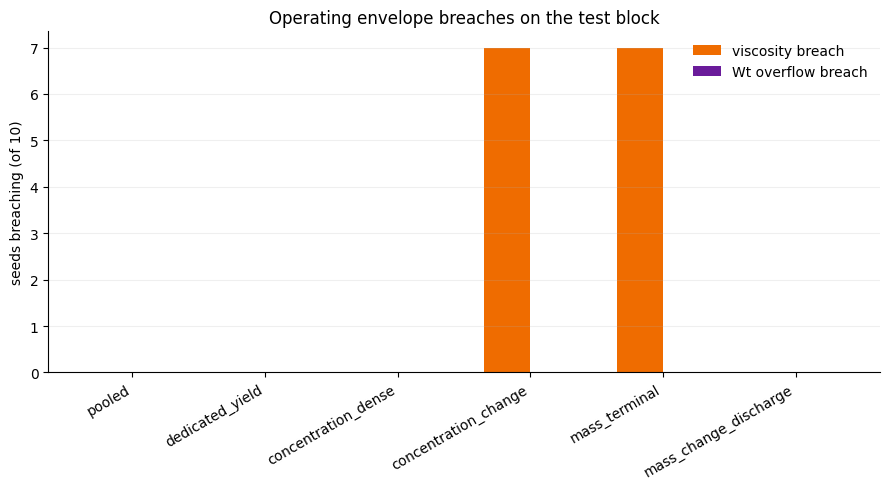

In [29]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(summary))
width = 0.35
ax.bar(x - width/2, summary["n_visc_breach"], width, label="viscosity breach", color="#EF6C00")
ax.bar(x + width/2, summary["n_wt_breach"], width, label="Wt overflow breach", color="#6A1B9A")
ax.set_xticks(x)
ax.set_xticklabels(summary["name"], rotation=30, ha="right")
n_test = int(summary["n_test_seeds"].iloc[0])
ax.set_ylabel(f"seeds breaching (of {n_test})")
ax.set_title("Operating envelope breaches on the test block")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

## BO convergence per run

Best-value-so-far against call index, one panel per run. Plotted as small multiples rather than
one shared axis -- the yield-ceiling run is in kg (maximized) and the 4 proxy runs are in
arbitrary, differently-scaled cost units (minimized), so a single shared y-axis would misrepresent
all but one of them. A flat tail means that run converged within budget; a still-sloping tail
means its result isn't trustworthy yet -- a bad final gap for that candidate could be an
under-optimized search, not genuine misalignment.

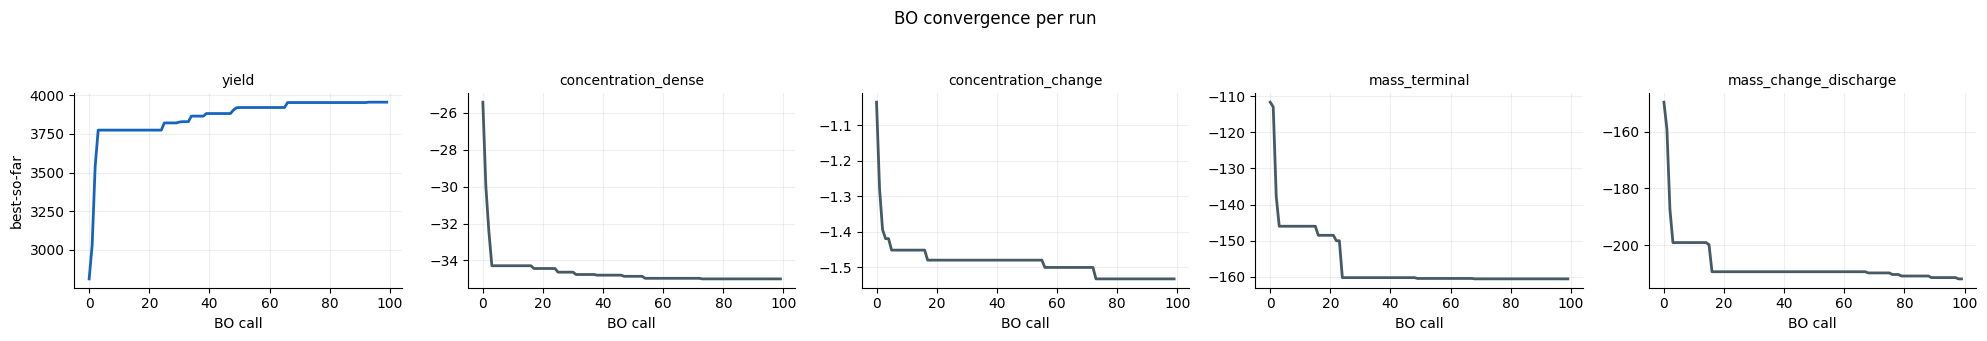

In [30]:
runs = ["yield"] + VARIANT_ORDER
fig, axes = plt.subplots(1, len(runs), figsize=(4 * len(runs), 3.2))
for ax, run in zip(axes, runs):
    sub = convergence[convergence["run"] == run]
    ax.plot(sub["call_idx"], sub["running_best"],
            color=REFERENCE_COLOR if run == "yield" else "#455A64", linewidth=2)
    ax.set_title(run, fontsize=10)
    ax.set_xlabel("BO call")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.2)
axes[0].set_ylabel("best-so-far")
fig.suptitle("BO convergence per run", y=1.05)
plt.tight_layout()
plt.show()

## Full verdict table

In [31]:
cols = ["name", "is_ceiling", "mean_yield_env_valid", "sd_yield_env_valid", "gap_kg", "gap_pct",
        "p_value", "verdict", "n_visc_breach", "n_wt_breach"]
summary[cols].round(3)

,name,is_ceiling,mean_yield_env_valid,sd_yield_env_valid,gap_kg,gap_pct,p_value,verdict,n_visc_breach,n_wt_breach
0,pooled,True,3880.416,267.507,NaN,NaN,NaN,NaN,0,0
1,dedicated_yield,False,3852.793,272.528,NaN,NaN,NaN,NaN,0,0
2,concentration_dense,False,3891.871,271.535,-11.456,-0.295,0.516,INCONCLUSIVE,0,0
3,concentration_change,False,1137.656,1775.197,2742.759,70.682,0.001,FAIL,7,0
4,mass_terminal,False,1124.272,1739.438,2756.143,71.027,0.001,FAIL,7,0
5,mass_change_discharge,False,3880.416,267.507,0.000,0.000,NaN,INCONCLUSIVE,0,0
